In [1]:
import numpy as np
import pandas as pd
import requests
import json,re,os,time,random
from tqdm import tqdm
import matplotlib.pyplot as plt 
%matplotlib inline
# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei'] # # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
import sys
if sys.platform.startswith('win'):
    plt.rcParams['font.family'] = ['sans-serif']  # windows系统
else:
    plt.rcParams["font.family"] = 'Arial Unicode MS'  # 苹果系统
from PIL import Image
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report,confusion_matrix




import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader
from torchvision import datasets,transforms,models
from tensorboardX import SummaryWriter



import warnings
warnings.filterwarnings("ignore")
# 迁移学习 

from torchvision.models import googlenet

from torchvision.models import densenet121,resnet50
torch.cuda.empty_cache()
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [2]:
img_size = 114 #  图像尺寸维度
num_classes = 10 # 分类个数
learning_rate = 0.001 # 学习率
num_epochs = 50 # 循环周期
batch_size = 128 # 一个批次大小

train_data_dir =  r'data/蘑菇是否有毒训练数据集/train/'
test_data_dir  =  r'data/蘑菇是否有毒训练数据集/test/'

os.makedirs('data',exist_ok=True)
os.makedirs('model',exist_ok=True)

In [3]:
# densenet renet

# 模型函数

In [4]:

def show_run_time(begin_time):
    """
    获取已使用时间
    begin_time = time.time()
    show_run_time(begin_time)
    """
    end_time = time.time()
    time_dif = end_time - begin_time
    seconds = time_dif/60
    seconds = round(seconds,1)
    print(f"花费时间{seconds}分钟")
    return time_dif



def load_weight2model(model, ckpt_path, map_location="cuda:0"):
    """
    加载模型权重
    """
    if not os.path.exists(ckpt_path):
        print("ckpt文件不存在，无法加载断点数据")
        return model, {"best_acc":-9999, "model_weight": None}
    ckpt = torch.load(ckpt_path, map_location=map_location)
    model.load_state_dict(ckpt["model_weight"])
    return model, ckpt

def train_one_epoch(model, dataloader, optimizer,loss_fn):
    
    """
    #训练一次epcoch模型
    计算loss还有acc
    """
    avg_loss = []
    pred_cls = [] # 预测类别
    real_cls = [] # 真实类别
    model.train()
    
    for batch_idx,(train_x,train_y) in enumerate(dataloader):
        train_x = train_x.to(device)
        real_cls.extend( train_y.numpy().tolist()  )
        train_y = train_y.to(device)
        
        #模型进行前向传播，得到结果
        pred = model(train_x)
        #从结果中计算损失
        loss = loss_fn(pred, train_y)
        #获得分类类别概率最大的类别ID
        cls_index = torch.argmax(pred, dim=1).cpu().numpy().tolist()
        pred_cls.extend(cls_index)
        #清空优化器保存的模型梯度，准备更细模型参数
        optimizer.zero_grad()
        #反向传播，计算梯度
        loss.backward()
        #优化器根据计算的梯度，更新模型的参数
        optimizer.step()
        avg_loss.append(loss.item())
    acc = accuracy_score(real_cls, pred_cls)
    avg_loss = np.array(avg_loss).mean()
    return acc, avg_loss

def eval_one_epoch(model, dataloader):
    """
    评价一次模型的效果，返回acc
    """
    pred_cls = []
    real_cls = []
    model.eval()
    for batch_idx,(train_x,train_y) in enumerate(dataloader):
        train_x = train_x.to(device)
        real_cls.extend( train_y.numpy().tolist()  )
        pred = model(train_x)
        cls_idx = torch.argmax(pred, dim=1).detach().cpu().numpy().tolist()
        pred_cls.extend(cls_idx)
    acc = accuracy_score(real_cls, pred_cls)
    f1  = f1_score(real_cls, pred_cls, average="macro")
    pre = precision_score(real_cls, pred_cls, average="macro")
    recall = recall_score(real_cls, pred_cls, average="macro")
    return acc, f1, pre,recall

# 数据集加载

In [5]:
train_transforms = transforms.Compose([
        transforms.CenterCrop( img_size ),#从中心开始裁剪，留下224x224的区域
        transforms.RandomHorizontalFlip(p=0.5),#随机水平翻转 选择一个概率
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])#均值，标准差（标准化操作）
    ])
test_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop( img_size ), # 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
# 训练集
train_dataset = datasets.ImageFolder(root = train_data_dir,
                               transform = train_transforms,
                              )
# 测试集
test_dataset = datasets.ImageFolder(root = test_data_dir ,
                               transform = test_transforms,
                              )
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
images,labels = iter(train_loader).next()
print('图像的尺寸',images.size())

index2label = train_dataset.classes
num_classes = len(index2label)
joblib.dump(index2label,'model/index2label.pkl')
# label2index
train_dataset.class_to_idx

图像的尺寸 torch.Size([128, 3, 114, 114])


{'无毒蘑菇': 0, '有毒蘑菇': 1}

# 模型对比

In [6]:

def build_densenet(num_classes):
    """
    构建 densenet 模型
    """
    model = densenet121(pretrained = True)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model



def build_resnet(num_classes):
    """
    构建 resnet 模型
    """
    model = resnet50(pretrained=True)
    in_features = model.fc.in_features
    model.fc =  nn.Sequential(
        nn.Linear(in_features, num_classes)
    )
    return model



# densenet调参训练

In [11]:

model_name = 'densenet'
from torch.optim.lr_scheduler import StepLR
begin_time = time.time()
num_epochs = 30
# 定义要调节的超参数空间
learning_rates = [0.001, 0.01,]
optimizers = {
    "Adam": optim.Adam,
}
results = {}
key2history = {}
# 网格搜索不同的超参数组合
for lr in learning_rates:
    for optimizer_name, optimizer_fn in optimizers.items():
        print(f"\nTraining with {optimizer_name} optimizer, lr={lr}")

        
        # 创建模型
        model = build_densenet(num_classes)
        model = model.to(device)

        # 选择优化器
        if optimizer_name == "SGD":
            optimizer = optimizer_fn(model.parameters(), lr=lr, momentum=0.9)
        else:
            optimizer = optimizer_fn(model.parameters(), lr=lr)

        # 损失函数
        criterion = nn.CrossEntropyLoss()

        # 学习率调度器
        scheduler = StepLR(optimizer, step_size=5, gamma=0.1) if optimizer_name != "Adam" else None
        acc_list = []
        loss_list = []
        # 训练模型
        for epoch in range(num_epochs):
            lasttime = time.time()
            acc, avg_loss = train_one_epoch(model,train_loader, optimizer, criterion)
            test_acc = eval_one_epoch(model, test_loader)[0]
            abstime = time.time()-lasttime
            print("epoch[{}/{}]\t train_loss={:.6f}\t train_acc={:.6f}\t test_acc={:.6f}\t time={:.1f}".format(
                epoch+1,num_epochs, avg_loss, acc, test_acc,abstime                                                              
                 ))
            acc_list.append(acc)
            loss_list.append(test_acc)
        
        acc = eval_one_epoch(model, test_loader)
        

        # 保存每个配置的结果
        key = f"{optimizer_name}-{lr}"
        results[key] = acc
        checkpoint = {}
        checkpoint["best_acc"] = acc
        checkpoint["model_weight"] = model.state_dict()
        if not os.path.exists("model"):
            os.mkdir('model')
        torch.save(checkpoint, f'model/{model_name}_{key}.pt')
        
        key2history[key] = {"acc":acc_list,"loss":loss_list}
print(show_run_time(begin_time))

#############
print(f"{model_name} 模型调参结果：")
sorted_result = sorted(results.items(),key=lambda x:x[1],reverse=True)
print(sorted_result)
print(f"{model_name} 最好模型：")
print( sorted_result[0] )


Training with Adam optimizer, lr=0.001
epoch[1/30]	 train_loss=0.608758	 train_acc=0.664959	 test_acc=0.622493	 time=78.5
epoch[2/30]	 train_loss=0.546548	 train_acc=0.704317	 test_acc=0.642982	 time=78.6
epoch[3/30]	 train_loss=0.506274	 train_acc=0.732447	 test_acc=0.652136	 time=78.7
epoch[4/30]	 train_loss=0.477685	 train_acc=0.756106	 test_acc=0.663470	 time=78.8
epoch[5/30]	 train_loss=0.452693	 train_acc=0.771042	 test_acc=0.663470	 time=78.3
epoch[6/30]	 train_loss=0.431662	 train_acc=0.785543	 test_acc=0.663034	 time=78.5
epoch[7/30]	 train_loss=0.402950	 train_acc=0.803314	 test_acc=0.637315	 time=78.4
epoch[8/30]	 train_loss=0.381907	 train_acc=0.820759	 test_acc=0.668265	 time=78.6
epoch[9/30]	 train_loss=0.365696	 train_acc=0.828282	 test_acc=0.668701	 time=78.4
epoch[10/30]	 train_loss=0.335489	 train_acc=0.844963	 test_acc=0.658239	 time=78.4
epoch[11/30]	 train_loss=0.319805	 train_acc=0.855975	 test_acc=0.677855	 time=78.8
epoch[12/30]	 train_loss=0.288320	 train_acc=

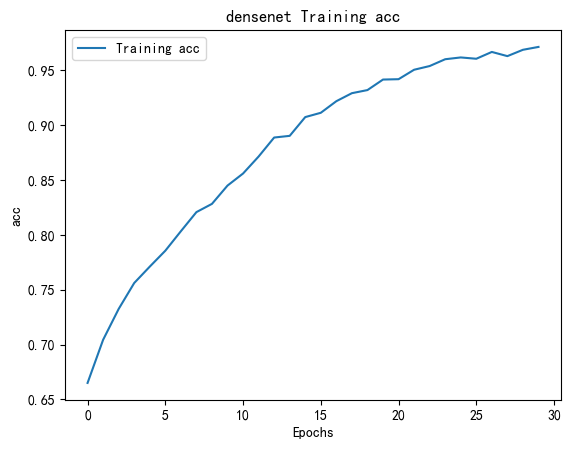

In [12]:
plt.plot(range(num_epochs), key2history[ sorted_result[0][0] ]['acc'], label='Training acc')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.title(f'{model_name} Training acc')
plt.legend()
plt.show()

# resnet模型调参训练

In [13]:

model_name = 'resnet'
from torch.optim.lr_scheduler import StepLR
begin_time = time.time()
num_epochs = 30
# 定义要调节的超参数空间
learning_rates = [0.001, 0.01,]
optimizers = {
    "Adam": optim.Adam,
}
results = {}
key2history = {}
# 网格搜索不同的超参数组合
for lr in learning_rates:
    for optimizer_name, optimizer_fn in optimizers.items():
        print(f"\nTraining with {optimizer_name} optimizer, lr={lr}")

        
        # 创建模型
        model = build_resnet(num_classes)
        model = model.to(device)

        # 选择优化器
        if optimizer_name == "SGD":
            optimizer = optimizer_fn(model.parameters(), lr=lr, momentum=0.9)
        else:
            optimizer = optimizer_fn(model.parameters(), lr=lr)

        # 损失函数
        criterion = nn.CrossEntropyLoss()

        # 学习率调度器
        scheduler = StepLR(optimizer, step_size=5, gamma=0.1) if optimizer_name != "Adam" else None
        acc_list = []
        loss_list = []
        # 训练模型
        for epoch in range(num_epochs):
            lasttime = time.time()
            acc, avg_loss = train_one_epoch(model,train_loader, optimizer, criterion)
            test_acc = eval_one_epoch(model, test_loader)[0]
            abstime = time.time()-lasttime
            print("epoch[{}/{}]\t train_loss={:.6f}\t train_acc={:.6f}\t test_acc={:.6f}\t time={:.1f}".format(
                epoch+1,num_epochs, avg_loss, acc, test_acc,abstime                                                              
                 ))
            acc_list.append(acc)
            loss_list.append(test_acc)
        
        acc = eval_one_epoch(model, test_loader)
        

        # 保存每个配置的结果
        key = f"{optimizer_name}-{lr}"
        results[key] = acc
        checkpoint = {}
        checkpoint["best_acc"] = acc
        checkpoint["model_weight"] = model.state_dict()
        if not os.path.exists("model"):
            os.mkdir('model')
        torch.save(checkpoint, f'model/{model_name}_{key}.pt')
        
        key2history[key] = {"acc":acc_list,"loss":loss_list}
print(show_run_time(begin_time))

#############
print(f"{model_name} 模型调参结果：")
sorted_result = sorted(results.items(),key=lambda x:x[1],reverse=True)
print(sorted_result)
print(f"{model_name} 最好模型：")
print( sorted_result[0] )


Training with Adam optimizer, lr=0.001
epoch[1/30]	 train_loss=0.633977	 train_acc=0.638901	 test_acc=0.615955	 time=78.1
epoch[2/30]	 train_loss=0.578210	 train_acc=0.678914	 test_acc=0.586748	 time=78.1
epoch[3/30]	 train_loss=0.569568	 train_acc=0.683602	 test_acc=0.628160	 time=78.1
epoch[4/30]	 train_loss=0.582836	 train_acc=0.688509	 test_acc=0.578466	 time=78.0
epoch[5/30]	 train_loss=0.553601	 train_acc=0.698757	 test_acc=0.630340	 time=78.0
epoch[6/30]	 train_loss=0.535716	 train_acc=0.710314	 test_acc=0.649956	 time=77.9
epoch[7/30]	 train_loss=0.505004	 train_acc=0.734300	 test_acc=0.641674	 time=77.9
epoch[8/30]	 train_loss=0.497545	 train_acc=0.745966	 test_acc=0.641238	 time=78.1
epoch[9/30]	 train_loss=0.478895	 train_acc=0.758504	 test_acc=0.652136	 time=77.9
epoch[10/30]	 train_loss=0.457520	 train_acc=0.771478	 test_acc=0.643418	 time=77.9
epoch[11/30]	 train_loss=0.438425	 train_acc=0.786851	 test_acc=0.613339	 time=78.3
epoch[12/30]	 train_loss=0.414746	 train_acc=

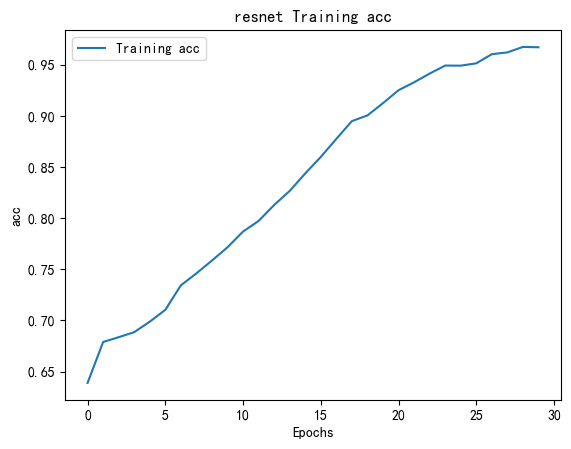

In [14]:
plt.plot(range(num_epochs), key2history[ sorted_result[0][0] ]['acc'], label='Training acc')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.title(f'{model_name} Training acc')
plt.legend()
plt.show()